# cGAN

In [1]:
import os
import json
import shutil
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.data import AUTOTUNE
from PIL import Image
from tqdm import tqdm  # Progress bar
import tensorflow as tf
from tensorflow.keras import layers
from scipy.linalg import sqrtm
import seaborn as sns

In [2]:
# Define paths
json_path = "photos.json"
photos_folder = "photos"
subset_folder = "subset-photos"

# Load JSON metadata
photos_data = []
with open(json_path, "r", encoding="utf-8") as f:
    for line in f:
        photos_data.append(json.loads(line))

# Convert to DataFrame
photos_df = pd.DataFrame(photos_data)

# Sample 20,000 images
subset_df = photos_df.sample(n=20000, random_state=42)
print(subset_df)

# Define label categories
LABELS = ["food", "drink", "inside", "outside"]

# Function to preprocess images
IMG_SIZE = 64  # Resize to 64x64 for faster training
BATCH_SIZE = 64

                      photo_id             business_id  \
32568   k_PSngRS22mSA1MypwrjPg  DzzVSYXadZ1_XgfGz_Loyw   
174911  D_94KivwVgitkzFIgE_KcQ  Xdzir62WKlSzeu4PMQtlBA   
132444  Hf39P7_G_eRCqfVwvMDV6g  z0HzwNBmx_BgdiYI4hLk3g   
46744   agxl4sABeRXwjLL506KMrQ  HzRSWmNxcEVQGrr1tun25w   
85073   7cZ0MREN2TwAAX4nnirQlA  aj0urA2r2WlqZKufeB5dpw   
...                        ...                     ...   
177761  xKmLKhK402BZtMYxBy29rw  5rSg5FARufPsy_ACLLhy-g   
17476   vct_qBbSdoWxUoAcHD4_0A  2NOCur2ahFs3ypwT3VPNQQ   
86822   BSsHTI1dGaXPCygJ8PW0VA  ckf4bmTIyheoCXfcFkYkaw   
164641  OybwIQj91sPjn70RSbw6Vw  bcfXCWaYxIN4UoV_94ksLQ   
129705  c92Dud10zgb1S6zasEB-DA  Y4Tdzmd0UC3JBqwZjMEJNw   

                             caption    label  
32568            Chocolate Croissant     food  
174911                                   food  
132444             Happy Anniversary    drink  
46744                 Frozen Puccino     food  
85073            Double Cheeseburger     food  
...            

In [7]:
# Define source and destination folders
photos_folder = "photos"  # Folder with all photos
subset_folder = "sub_photos"  # Folder for subset images

# Create the new folder if it doesn't exist
os.makedirs(subset_folder, exist_ok=True)

# Get a list of already moved images
existing_images = set(os.listdir(subset_folder))  # Set of already moved files

# Count how many images need to be moved
remaining_images = [photo_id for photo_id in subset_df["photo_id"] if f"{photo_id}.jpg" not in existing_images]

if not remaining_images:
    print(f"All subset images are already moved to {subset_folder}")
else:
    print(f"⚠ Moving {len(remaining_images)} images to {subset_folder}...")

    moved_count = 0
    for photo_id in remaining_images:
        src_path = os.path.join(photos_folder, f"{photo_id}.jpg")
        
        dest_path = os.path.join(subset_folder, f"{photo_id}.jpg")
        if os.path.exists(src_path):
            shutil.move(src_path, dest_path)
            moved_count += 1

    print(f"Moved {moved_count} new images to {subset_folder}")

All subset images are already moved to sub_photos


In [8]:
def load_and_preprocess_image(img_path):
    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))  
    img = img_to_array(img) / 127.5 - 1  # Normalize to [-1, 1]
    return img

# Load images and labels
image_paths, labels = [], []
skipped_images = []
for _, row in subset_df.iterrows():
    img_path = os.path.join(subset_folder, row["photo_id"] + ".jpg")
    if os.path.exists(img_path):  
        try:
            # Try loading image to check if it's valid
            _ = load_and_preprocess_image(img_path)
            image_paths.append(img_path)
            # Handle label parsing
            raw_label = row["label"].strip("[]").replace("'", "")
            label_list = [lbl.strip() for lbl in raw_label.split(",")]
            # One-hot encode labels
            label_vector = [1 if lbl in label_list else 0 for lbl in LABELS]
            labels.append(label_vector)
        except (Image.UnidentifiedImageError, OSError):
            skipped_images.append(img_path)

# Convert to NumPy arrays
images_np = np.array([load_and_preprocess_image(p) for p in image_paths])
labels_np = np.array(labels)

# Create TensorFlow dataset
dataset = tf.data.Dataset.from_tensor_slices((images_np, labels_np))
dataset = dataset.shuffle(10000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [9]:
import tensorflow as tf

tfrecord_path = "yelp_dataset_for_cGAN.tfrecord"

def serialize_example(image, label):
    feature = {
        "image": tf.train.Feature(bytes_list=tf.train.BytesList(value=[tf.io.encode_jpeg(tf.cast((image + 1) * 127.5, tf.uint8)).numpy()])),
        "label": tf.train.Feature(int64_list=tf.train.Int64List(value=label))
    }
    example_proto = tf.train.Example(features=tf.train.Features(feature=feature))
    return example_proto.SerializeToString()

with tf.io.TFRecordWriter(tfrecord_path) as writer:
    for i in range(len(images_np)):
        example = serialize_example(images_np[i], labels_np[i])
        writer.write(example)

print(f"Dataset saved to {tfrecord_path}")

Dataset saved to yelp_dataset_for_cGAN.tfrecord


Skipped 6 corrupted images.


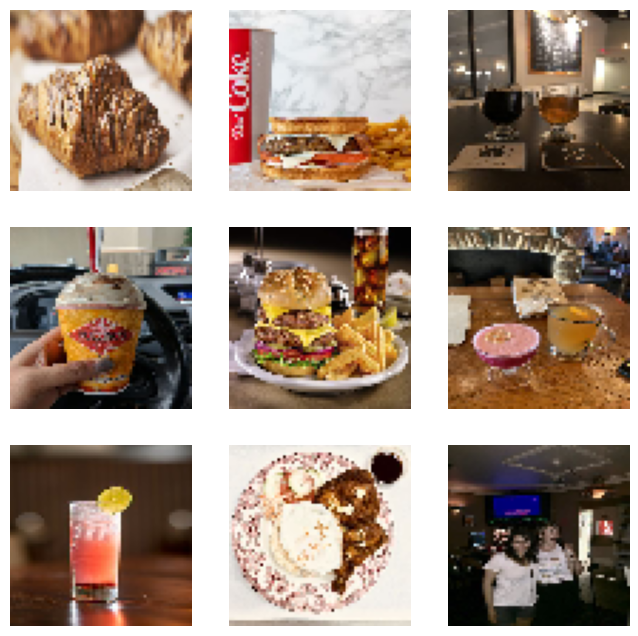

In [10]:
print(f"Skipped {len(skipped_images)} corrupted images.")
# Show some images

plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow((images_np[i] + 1) / 2)  # Convert back to [0,1]
    plt.axis("off")
plt.show()

In [11]:
NOISE_DIM = 100  # Size of the random noise vector

def build_generator():
    noise_input = layers.Input(shape=(NOISE_DIM,))
    label_input = layers.Input(shape=(4,))  # One-hot encoded labels

    # Concatenate noise and label
    x = layers.Concatenate()([noise_input, label_input])

    # Fully connected layers
    x = layers.Dense(8 * 8 * 256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Reshape((8, 8, 256))(x)

    # Convolutional layers (upsampling)
    x = layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(64, (4, 4), strides=(2, 2), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(3, (4, 4), strides=(2, 2), padding="same", activation="tanh")(x)

    return tf.keras.Model([noise_input, label_input], x, name="Generator")

generator = build_generator()
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 104)       │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16384)     │  1,703,936 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 16384)     │     65,536 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 16384)     │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 8, 8, 256) │          0 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │    524,288 │ reshape[0][0]     │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 32, 32,    │    131,072 │ leaky_re_lu_1[0]… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 64, 64, 3) │      3,075 │ leaky_re_lu_2[0]… │
│ (Conv2DTranspose)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,428,675 (9.26 MB)

 Trainable params: 2,395,523 (9.14 MB)

 Non-trainable params: 33,152 (129.50 KB)

In [12]:
def build_discriminator():
    img_input = layers.Input(shape=(64, 64, 3))
    label_input = layers.Input(shape=(4,))

    # Expand label to match image size and concatenate
    label_expanded = layers.Dense(64 * 64 * 1)(label_input)
    label_expanded = layers.Reshape((64, 64, 1))(label_expanded)
    x = layers.Concatenate()([img_input, label_expanded])

    # Convolutional layers
    x = layers.Conv2D(64, (4, 4), strides=(2, 2), padding="same")(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, (4, 4), strides=(2, 2), padding="same")(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(256, (4, 4), strides=(2, 2), padding="same")(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(1, activation="sigmoid")(x)

    return tf.keras.Model([img_input, label_input], x, name="Discriminator")

discriminator = build_discriminator()
discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4096)      │     20,480 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 64, 64, 1) │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 64, 64, 4) │          0 │ input_layer_2[0]… │
│ (Concatenate)       │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      4,160 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 32, 32,    │          0 │ conv2d[0][0]      │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32, 32,    │          0 │ leaky_re_lu_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │    131,200 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 16, 16,    │          0 │ conv2d_1[0][0]    │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16, 16,    │          0 │ leaky_re_lu_4[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 256) │    524,544 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 8, 8, 256) │          0 │ conv2d_2[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 8, 8, 256) │          0 │ leaky_re_lu_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16384)     │          0 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │     16,385 │ flatten[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 696,769 (2.66 MB)

 Trainable params: 696,769 (2.66 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

In [14]:
@tf.function
def train_step(images, labels):
    noise = tf.random.normal([images.shape[0], NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator([noise, labels], training=True)

        real_output = discriminator([images, labels], training=True)
        fake_output = discriminator([generated_images, labels], training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_gen = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_disc = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_gen, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_disc, discriminator.trainable_variables))

    return gen_loss, disc_loss

In [15]:
# Ensure TensorFlow is using CUDA
physical_devices = tf.config.experimental.list_physical_devices("GPU")
if physical_devices:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print(f"Using GPU: {physical_devices[0]}")
else:
    print("No GPU found. Using CPU.")

# Updated training loop
EPOCHS = 50  # Set to higher value since we're optimizing speed

for epoch in range(EPOCHS):
    start_time = time.time()
    epoch_g_loss = []
    epoch_d_loss = []

    progress_bar = tqdm(dataset, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=True)

    for image_batch, label_batch in progress_bar:
        g_loss, d_loss = train_step(image_batch, label_batch)
        epoch_g_loss.append(g_loss.numpy())
        epoch_d_loss.append(d_loss.numpy())

        # Update progress bar with loss
        progress_bar.set_postfix(G_Loss=f"{g_loss.numpy():.4f}", D_Loss=f"{d_loss.numpy():.4f}")

    end_time = time.time()
    avg_g_loss = np.mean(epoch_g_loss)
    avg_d_loss = np.mean(epoch_d_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Time: {end_time - start_time:.2f}s | "
          f"Generator Loss: {avg_g_loss:.4f} | Discriminator Loss: {avg_d_loss:.4f}")

No GPU found. Using CPU.


Epoch 1/50:   0%|                                       | 0/313 [00:00<?, ?it/s]/opt/anaconda3/lib/python3.11/site-packages/keras/src/backend/tensorflow/nn.py:780: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(
Epoch 1/50: 100%|█| 313/313 [02:35<00:00,  1.49it/s, D_Loss=1.2432, G_Loss=3.7272025-03-27 23:09:55.002035: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Epoch 1/50: 100%|█| 313/313 [02:35<00:00,  2.01it/s, D_Loss=1.2432, G_Loss=3.727


Epoch 1/50 | Time: 155.38s | Generator Loss: 2.1017 | Discriminator Loss: 0.7498


Epoch 2/50: 100%|█| 313/313 [02:34<00:00,  2.43it/s, D_Loss=1.0087, G_Loss=0.9652025-03-27 23:12:29.672475: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Epoch 2/50: 100%|█| 313/313 [02:34<00:00,  2.02it/s, D_Loss=1.0087, G_Loss=0.965


Epoch 2/50 | Time: 154.67s | Generator Loss: 1.3616 | Discriminator Loss: 0.9541


...

Epoch 48/50 | Time: 183.30s | Generator Loss: 3.1779 | Discriminator Loss: 0.4926


Epoch 49/50: 100%|█| 313/313 [03:04<00:00,  1.69it/s, D_Loss=0.8464, G_Loss=1.98


Epoch 49/50 | Time: 184.91s | Generator Loss: 2.9402 | Discriminator Loss: 0.5059


Epoch 50/50: 100%|█| 313/313 [03:04<00:00,  1.70it/s, D_Loss=0.3739, G_Loss=3.30

Epoch 50/50 | Time: 184.48s | Generator Loss: 2.9507 | Discriminator Loss: 0.4989


Images saved in generated_samples


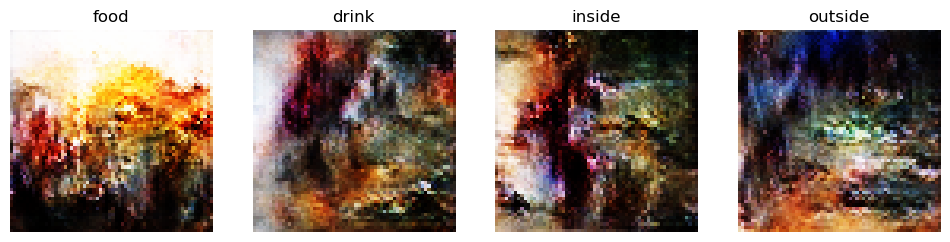

In [16]:
save_dir = "generated_samples"
os.makedirs(save_dir, exist_ok=True)

def generate_save_plot_images():
    noise = tf.random.normal([4, NOISE_DIM])
    sample_labels = tf.eye(4)  # One-hot labels for food, drink, inside, outside
    generated_images = generator([noise, sample_labels], training=False)

    fig, axs = plt.subplots(1, 4, figsize=(12, 3))
    for i, img in enumerate(generated_images):
        img = (img + 1) / 2  # Convert to [0,1] range
        plt.imsave(f"{save_dir}/{LABELS[i]}.png", img.numpy())  # Save images
        axs[i].imshow(img)
        axs[i].axis("off")
        axs[i].set_title(LABELS[i])
    
    print(f"Images saved in {save_dir}")
    plt.show()
    

generate_save_plot_images()

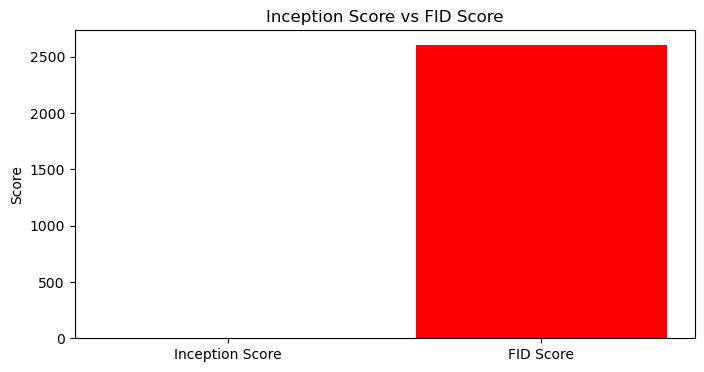

In [31]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm

def calculate_is_fid(real_images, fake_images):
    # Convert tensors to NumPy arrays
    real_images = real_images.numpy()
    fake_images = fake_images.numpy()

    # Compute statistics for IS
    p_yx = tf.nn.softmax(fake_images)  # Using fake images for IS
    p_y = tf.reduce_mean(p_yx, axis=0)
    kl_div = tf.reduce_sum(p_yx * tf.math.log(p_yx / p_y), axis=1)
    inception_score = tf.exp(tf.reduce_mean(kl_div))

    # **Reduce Dimensionality: Compute mean across spatial dimensions**
    mu_real = np.mean(real_images, axis=(0, 1, 2))  # Mean per channel
    mu_fake = np.mean(fake_images, axis=(0, 1, 2))  # Mean per channel

    # Compute covariance only for channels (3x3 matrix instead of huge 192000x192000)
    real_images_flat = real_images.reshape(real_images.shape[0], -1)  # (num_samples, features)
    fake_images_flat = fake_images.reshape(fake_images.shape[0], -1)  # (num_samples, features)
    
    sigma_real = np.cov(real_images_flat, rowvar=False)
    sigma_fake = np.cov(fake_images_flat, rowvar=False)

    # Compute FID
    diff = mu_real - mu_fake
    sqrt_cov = sqrtm(sigma_real @ sigma_fake)

    # Ensure sqrt_cov is real-valued
    if np.iscomplexobj(sqrt_cov):
        sqrt_cov = sqrt_cov.real

    fid_score = np.linalg.norm(diff) + np.trace(sigma_real + sigma_fake - 2 * sqrt_cov)

    return inception_score.numpy(), fid_score

# Generate fake images
num_images = 1000
NOISE_DIM = 100  
noise = tf.random.normal([num_images, NOISE_DIM])
labels = tf.one_hot(np.random.choice(4, num_images), depth=4)
generated_images = generator([noise, labels], training=False)

# Select real images
real_images, _ = next(iter(dataset.take(1)))

# Ensure real and fake images have the same shape
real_images = real_images[:num_images]

# Compute scores
is_score, fid_score = calculate_is_fid(real_images, generated_images)

# **Plot IS and FID scores**
plt.figure(figsize=(8, 4))
plt.bar(["Inception Score", "FID Score"], [is_score, fid_score], color=['blue', 'red'])
plt.ylabel("Score")
plt.title("Inception Score vs FID Score")
plt.show()

In [36]:
print("Inception Score", is_score)
print("FID Score", fid_score)

Inception Score 1.2030339
FID Score 2605.8033126957644


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

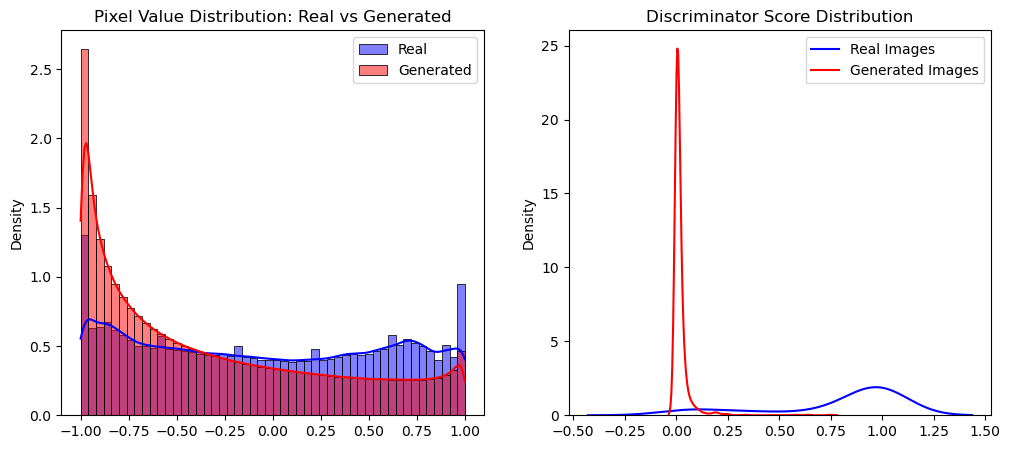

In [19]:
def plot_distributions(real_images, fake_images, real_labels, fake_labels, discriminator):
    # Flatten images only for visualization, keep original tensors for discriminator input
    real_images_flat = tf.reshape(real_images, [-1])  # Flatten pixel values for visualization
    fake_images_flat = tf.reshape(fake_images, [-1])

    # Plot pixel distributions
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(real_images_flat.numpy(), bins=50, color='blue', label='Real', kde=True, stat="density")
    sns.histplot(fake_images_flat.numpy(), bins=50, color='red', label='Generated', kde=True, stat="density")
    plt.title("Pixel Value Distribution: Real vs Generated")
    plt.legend()

    # Get discriminator outputs by passing both images and labels (keep as tensors)
    real_scores = discriminator([real_images, real_labels])
    fake_scores = discriminator([fake_images, fake_labels])

    # Convert discriminator outputs to numpy for plotting
    real_scores = real_scores.numpy()
    fake_scores = fake_scores.numpy()

    # Plot Discriminator Scores
    plt.subplot(1, 2, 2)
    sns.kdeplot(real_scores.flatten(), color='blue', label="Real Images")
    sns.kdeplot(fake_scores.flatten(), color='red', label="Generated Images")
    plt.title("Discriminator Score Distribution")
    plt.legend()

    plt.show()

# Select real images and labels
real_images, real_labels = next(iter(dataset.take(1)))
real_images = real_images[:1000]  # Use consistent number of real images
real_labels = real_labels[:1000]  # Corresponding labels

# Reuse generated images and labels from the previous IS/FID generation step
fake_images = generated_images  # Already generated fake images
fake_labels = labels  # Labels used during generation

# Plot distributions with real images, fake images, and labels
plot_distributions(real_images, fake_images, real_labels, fake_labels, discriminator)

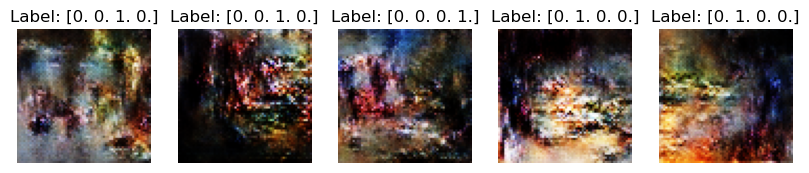

In [20]:
# Show 5 generated images with labels
num_images_to_show = 5

# Generate a plot
plt.figure(figsize=(10, 10))

for i in range(num_images_to_show):
    plt.subplot(1, num_images_to_show, i + 1)
    plt.imshow((generated_images[i] * 0.5) + 0.5)  # Rescale images to [0, 1] for visualization
    plt.title(f"Label: {labels[i].numpy()}")
    plt.axis('off')

plt.show()

## Results and Observations
- **Inception Score (IS): 1.2030**
- **FID Score: 2605.80**
- *The generator ran for 50 epochs and has begun learning, with the tail of the generated image distribution gradually shifting toward the real distribution.*
- *The generator seem to understand the low level features, and with more epochs while utilizing GPU will allow the generator to perform betterand faster.*

## Tuning

In [21]:
NOISE_DIM = 128  # Increased noise dimension for better diversity
LABEL_DIM = 4    # One-hot encoded labels
IMG_SHAPE = (64, 64, 3)  # Image shape

# Generator with improved architecture
def build_generator():
    noise_input = layers.Input(shape=(NOISE_DIM,))
    label_input = layers.Input(shape=(LABEL_DIM,))
    
    x = layers.Concatenate()([noise_input, label_input])
    x = layers.Dense(8 * 8 * 512, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Reshape((8, 8, 512))(x)
    
    x = layers.Conv2DTranspose(256, (3, 3), strides=(2, 2), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    
    x = layers.Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    
    x = layers.Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    
    x = layers.Conv2DTranspose(3, (3, 3), strides=(1, 1), padding='same', activation='tanh')(x)
    
    return tf.keras.Model([noise_input, label_input], x, name='Generator')

generator = build_generator()
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 132)       │          0 │ input_layer_4[0]… │
│ (Concatenate)       │                   │            │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32768)     │  4,325,376 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32768)     │    131,072 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 32768)     │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 8, 8, 512) │          0 │ leaky_re_lu_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 16, 16,    │  1,179,648 │ reshape_2[0][0]   │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 32, 32,    │    294,912 │ leaky_re_lu_7[0]… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_8       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_5  │ (None, 64, 64,    │     73,728 │ leaky_re_lu_8[0]… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_9       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_6  │ (None, 64, 64, 3) │      1,731 │ leaky_re_lu_9[0]… │
│ (Conv2DTranspose)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 6,008,259 (22.92 MB)

 Trainable params: 5,941,827 (22.67 MB)

 Non-trainable params: 66,432 (259.50 KB)

In [22]:
# Discriminator with Spectral Normalization
def build_discriminator():
    img_input = layers.Input(shape=IMG_SHAPE)
    label_input = layers.Input(shape=(LABEL_DIM,))
    
    label_expanded = layers.Dense(64 * 64 * 1)(label_input)
    label_expanded = layers.Reshape((64, 64, 1))(label_expanded)
    x = layers.Concatenate()([img_input, label_expanded])
    
    x = layers.Conv2D(64, (3, 3), strides=(2, 2), padding='same')(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Conv2D(128, (3, 3), strides=(2, 2), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Conv2D(256, (3, 3), strides=(2, 2), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Flatten()(x)
    x = layers.Dense(1, activation='sigmoid')(x)
    
    return tf.keras.Model([img_input, label_input], x, name='Discriminator')

discriminator = build_discriminator()
discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 4096)      │     20,480 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 64, 64, 1) │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 64, 64, 4) │          0 │ input_layer_6[0]… │
│ (Concatenate)       │                   │            │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │      2,368 │ concatenate_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_10      │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32, 32,    │          0 │ leaky_re_lu_10[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │     73,856 │ dropout_3[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_11      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 16, 16,    │          0 │ leaky_re_lu_11[0… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 8, 8, 256) │    295,168 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 256) │      1,024 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_12      │ (None, 8, 8, 256) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 8, 8, 256) │          0 │ leaky_re_lu_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 16384)     │          0 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │     16,385 │ flatten_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 409,793 (1.56 MB)

 Trainable params: 409,025 (1.56 MB)

 Non-trainable params: 768 (3.00 KB)

In [23]:
def generator_loss(fake_output):
    return tf.keras.losses.BinaryCrossentropy(from_logits=True)(tf.ones_like(fake_output) * 0.9, fake_output)  # Label smoothing

def discriminator_loss(real_output, fake_output):
    real_loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)(tf.ones_like(real_output) * 0.9, real_output)
    fake_loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

# Tuned optimizers
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.5)

In [24]:
# Training function
@tf.function
def train_step(images, labels):
    noise = tf.random.normal([images.shape[0], NOISE_DIM])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator([noise, labels], training=True)
        real_output = discriminator([images, labels], training=True)
        fake_output = discriminator([generated_images, labels], training=True)
        
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)
    
    gradients_gen = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_disc = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    
    generator_optimizer.apply_gradients(zip(gradients_gen, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_disc, discriminator.trainable_variables))
    
    return gen_loss, disc_loss

In [25]:
# Training loop with progressive training

EPOCHS = 75
for epoch in range(EPOCHS):
    start_time = time.time()
    epoch_g_loss, epoch_d_loss = [], []
    progress_bar = tqdm(dataset, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=True)
    
    for image_batch, label_batch in progress_bar:
        g_loss, d_loss = train_step(image_batch, label_batch)
        epoch_g_loss.append(g_loss.numpy())
        epoch_d_loss.append(d_loss.numpy())
        progress_bar.set_postfix(G_Loss=f"{g_loss.numpy():.4f}", D_Loss=f"{d_loss.numpy():.4f}")
    
    avg_g_loss = np.mean(epoch_g_loss)
    avg_d_loss = np.mean(epoch_d_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} | Time: {time.time() - start_time:.2f}s | Generator Loss: {avg_g_loss:.4f} | Discriminator Loss: {avg_d_loss:.4f}")


Epoch 1/75:   0%|                                       | 0/313 [00:00<?, ?it/s]/opt/anaconda3/lib/python3.11/site-packages/keras/src/backend/tensorflow/nn.py:780: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(
Epoch 1/75: 100%|█| 313/313 [04:59<00:00,  1.05it/s, D_Loss=1.5917, G_Loss=0.951


Epoch 1/75 | Time: 299.20s | Generator Loss: 0.9892 | Discriminator Loss: 1.6211


Epoch 2/75: 100%|█| 313/313 [04:54<00:00,  1.06it/s, D_Loss=1.6495, G_Loss=0.818


Epoch 2/75 | Time: 294.37s | Generator Loss: 0.9213 | Discriminator Loss: 1.4961


Epoch 3/75: 100%|█| 313/313 [04:50<00:00,  1.08it/s, D_Loss=1.4195, G_Loss=0.932


...

Epoch 73/75 | Time: 278.41s | Generator Loss: 1.5697 | Discriminator Loss: 0.9734


Epoch 74/75: 100%|█| 313/313 [04:38<00:00,  1.12it/s, D_Loss=0.8635, G_Loss=1.64


Epoch 74/75 | Time: 278.37s | Generator Loss: 1.5906 | Discriminator Loss: 0.9588


Epoch 75/75: 100%|█| 313/313 [04:40<00:00,  1.12it/s, D_Loss=0.8538, G_Loss=1.82

Epoch 75/75 | Time: 280.21s | Generator Loss: 1.6585 | Discriminator Loss: 0.9599


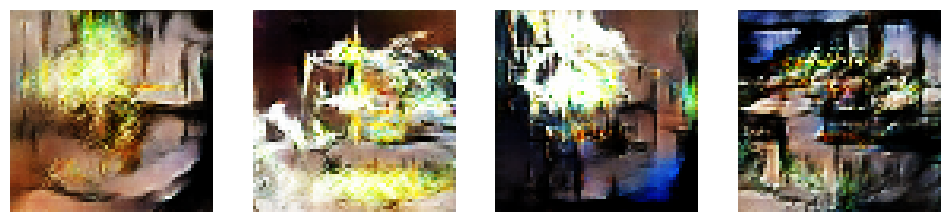

In [26]:
# Save generated images
def generate_save_plot_images():
    save_dir = "generated_samples_tune"
    os.makedirs(save_dir, exist_ok=True)
    
    noise = tf.random.normal([4, NOISE_DIM])
    sample_labels = tf.eye(4)  # One-hot labels for food, drink, inside, outside
    generated_images = generator([noise, sample_labels], training=False)
    
    fig, axs = plt.subplots(1, 4, figsize=(12, 3))
    for i, img in enumerate(generated_images):
        img = (img + 1) / 2  # Convert to [0,1] range
        plt.imsave(f"{save_dir}/label_{i}.png", img.numpy())
        axs[i].imshow(img)
        axs[i].axis("off")
    plt.show()

generate_save_plot_images()

In [33]:
print("Inception Score", is_score)
print("FID Score", fid_score)

Inception Score 1.4143053
FID Score nan


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

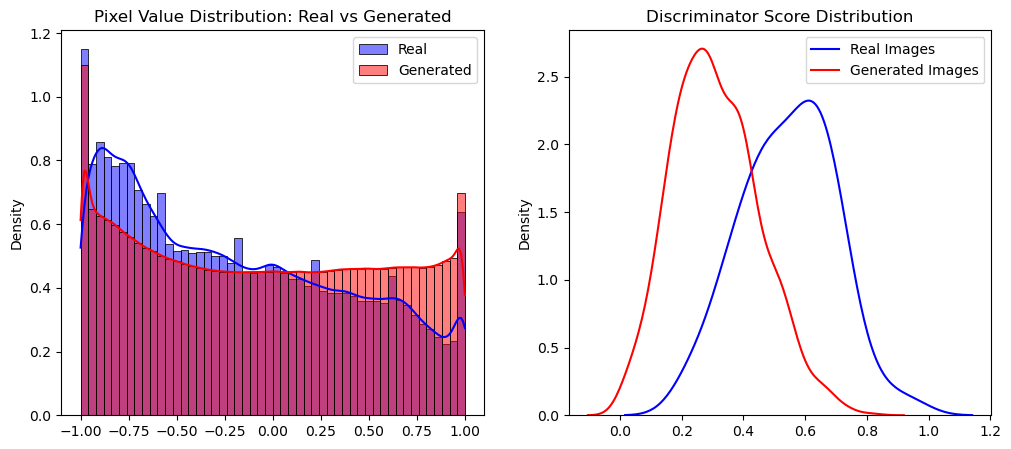

In [29]:
def plot_distributions(real_images, fake_images, real_labels, fake_labels, discriminator):
    real_images_flat = tf.reshape(real_images, [-1])
    fake_images_flat = tf.reshape(fake_images, [-1])
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(real_images_flat.numpy(), bins=50, color='blue', label='Real', kde=True, stat="density")
    sns.histplot(fake_images_flat.numpy(), bins=50, color='red', label='Generated', kde=True, stat="density")
    plt.title("Pixel Value Distribution: Real vs Generated")
    plt.legend()
    
    real_scores = discriminator([real_images, real_labels]).numpy()
    fake_scores = discriminator([fake_images, fake_labels]).numpy()
    
    plt.subplot(1, 2, 2)
    sns.kdeplot(real_scores.flatten(), color='blue', label="Real Images")
    sns.kdeplot(fake_scores.flatten(), color='red', label="Generated Images")
    plt.title("Discriminator Score Distribution")
    plt.legend()
    plt.show()

# Select real images and labels
real_images, real_labels = next(iter(dataset.take(1)))
real_images = real_images[:1000]  # Match count
real_labels = real_labels[:1000]
plot_distributions(real_images, generated_images, real_labels, labels, discriminator)

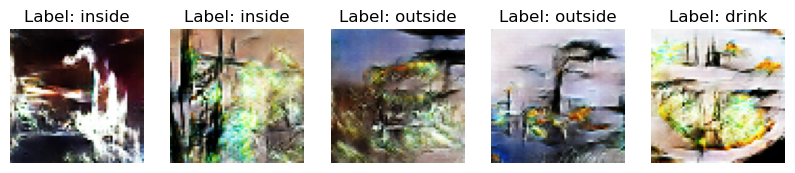

In [39]:
plt.figure(figsize=(10, 10))

for i in range(num_images_to_show):
    plt.subplot(1, num_images_to_show, i + 1)
    plt.imshow((generated_images[i] * 0.5) + 0.5)  # Rescale images to [0, 1] for visualization
    
    # Convert one-hot encoding to class index and get class name
    class_index = labels[i].numpy().argmax()
    class_label = LABELS[class_index]

    plt.title(f"Label: {class_label}")
    plt.axis('off')

plt.show()